In [1]:
pip install xgboost scikit-learn imbalanced-learn pandas numpy joblib

   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.5/48.9 MB 2.6 MB/s eta 0:00:19
   - -------------------------------------- 1.3/48.9 MB 2.8 MB/s eta 0:00:17
   - -------------------------------------- 1.6/48.9 MB 2.7 MB/s eta 0:00:18
   - -------------------------------------- 2.4/48.9 MB 2.8 MB/s eta 0:00:17
   -- ------------------------------------- 3.1/48.9 MB 2.9 MB/s eta 0:00:16
   --- ------------------------------------ 3.9/48.9 MB 3.1 MB/s eta 0:00:15
   --- ------------------------------------ 4.5/48.9 MB 3.2 MB/s eta 0:00:14
   ---- ----------------------------------- 5.2/48.9 MB 3.1 MB/s eta 0:00:15
   ---- ----------------------------------- 6.0/48.9 MB 3.2 MB/s eta 0:00:14
   ----- ---------------------------------- 7.3/48.9 MB 3.4 MB/s eta 0:00:13
   ------ --------------------------------- 8.4/48.9 MB 3.6 MB/s eta 0:00:12
   ------- --


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
!python -m pip install imbalanced-learn

Defaulting to user installation because normal site-packages is not writeable

   ---------------------------------------- 0/2 [sklearn-compat]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   ---------------------------------------- 2/2 [imbalanced-learn]




[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
!python -m pip install xgboost

Defaulting to user installation because normal site-packages is not writeable
  Using cached xgboost-3.4.1-py3-none-win_amd64.whl.metadata (2.0 kB)
Using cached xgboost-3.4.1-py3-none-win_amd64.whl (48.9 MB)



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from imblearn.over_sampling import SMOTE
import xgboost as xgb
import joblib

# Load dataset (Make sure the CSV file is in your working directory)
df = pd.read_csv(r'C:\Users\Hp\OneDrive\Desktop\transaction-fraud\PS_20174392719_1491204439457_log.csv')

print(f"Dataset Shape: {df.shape}")
print(f"Fraud distribution:\n{df['isFraud'].value_counts(normalize=True)}")

Dataset Shape: (6362620, 11)
Fraud distribution:
isFraud
0    0.998709
1    0.001291
Name: proportion, dtype: float64


In [7]:
# Drop columns that don't help prediction or cause data leakage
cols_to_drop = ['nameOrig', 'nameDest', 'isFlaggedFraud']
df = df.drop(columns=cols_to_drop, errors='ignore')

# Encode categorical variables (e.g., transaction 'type': CASH-IN, CASH-OUT, TRANSFER, etc.)
le = LabelEncoder()
if 'type' in df.columns:
    df['type'] = le.fit_transform(df['type'])

# Add custom domain features for transaction discrepancies
df['errorBalanceOrg'] = df['newbalanceOrig'] + df['amount'] - df['oldbalanceOrg']
df['errorBalanceDest'] = df['newbalanceDest'] + df['amount'] - df['oldbalanceDest']

# Define Features (X) and Target (y)
X = df.drop(columns=['isFraud'])
y = df['isFraud']

# Stratified Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [8]:
print("Applying SMOTE to handle class imbalance...")
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print(f"Resampled training shape: {X_train_resampled.shape}")
print(f"Resampled class distribution:\n{y_train_resampled.value_counts()}")

Applying SMOTE to handle class imbalance...
Resampled training shape: (10167052, 9)
Resampled class distribution:
isFraud
0    5083526
1    5083526
Name: count, dtype: int64


In [9]:
print("Training XGBoost Classifier...")
model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

model.fit(X_train_resampled, y_train_resampled)

# Evaluate Model on Test Set
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))

print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Save Model and Label Encoder for Production API
joblib.dump(model, 'fraud_detection_model.pkl')
joblib.dump(le, 'label_encoder.pkl')
print("\nModel successfully trained and saved as 'fraud_detection_model.pkl'!")

Training XGBoost Classifier...

--- Classification Report ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       0.88      1.00      0.94      1643

    accuracy                           1.00   1272524
   macro avg       0.94      1.00      0.97   1272524
weighted avg       1.00      1.00      1.00   1272524

ROC-AUC Score: 0.9996
Confusion Matrix:
[[1270664     217]
 [      2    1641]]

Model successfully trained and saved as 'fraud_detection_model.pkl'!


In [10]:
import pandas as pd
import joblib

# 1. Load the saved model and label encoder
model = joblib.load('fraud_detection_model.pkl')
le = joblib.load('label_encoder.pkl')

# 2. Create a sample transaction dictionary matching your dataset features
sample_transaction = {
    'step': 1,
    'type': 'TRANSFER',          # Transaction type
    'amount': 181000.00,         # Transaction amount
    'oldbalanceOrg': 181000.00,  # Sender's initial balance
    'newbalanceOrig': 0.00,      # Sender's new balance after transaction
    'oldbalanceDest': 0.00,      # Receiver's initial balance
    'newbalanceDest': 181000.00  # Receiver's new balance
}

# 3. Convert dictionary to a Pandas DataFrame
df_sample = pd.DataFrame([sample_transaction])

# 4. Apply the exact same preprocessing steps
# Encode the categorical 'type' column using the saved LabelEncoder
df_sample['type'] = le.transform(df_sample['type'])

# Re-create the custom error balance features added during training
df_sample['errorBalanceOrg'] = df_sample['newbalanceOrig'] + df_sample['amount'] - df_sample['oldbalanceOrg']
df_sample['errorBalanceDest'] = df_sample['newbalanceDest'] + df_sample['amount'] - df_sample['oldbalanceDest']

# 5. Make the prediction
prediction = model.predict(df_sample)[0]
fraud_probability = model.predict_proba(df_sample)[0][1]

# 6. Display results
print(f"Fraud Probability: {fraud_probability * 100:.2f}%")
if prediction == 1:
    print("🚨 Alert: This transaction is flagged as FRAUDULENT!")
else:
    print("✅ Safe: This transaction is Legitimate.")

Fraud Probability: 99.94%
🚨 Alert: This transaction is flagged as FRAUDULENT!


In [12]:
!python -m pip install shap

Defaulting to user installation because normal site-packages is not writeable
  Using cached numba-0.67.0-cp313-cp313-win_amd64.whl.metadata (2.8 kB)
  Using cached llvmlite-0.49.0-cp313-cp313-win_amd64.whl.metadata (5.2 kB)
  Using cached cloudpickle-3.1.2-py3-none-any.whl.metadata (7.1 kB)
Using cached cloudpickle-3.1.2-py3-none-any.whl (22 kB)
Using cached llvmlite-0.49.0-cp313-cp313-win_amd64.whl (41.9 MB)
Using cached numba-0.67.0-cp313-cp313-win_amd64.whl (2.8 MB)

   -------- ------------------------------- 1/5 [llvmlite]
   -------- ------------------------------- 1/5 [llvmlite]
   -------- ------------------------------- 1/5 [llvmlite]
   -------- ------------------------------- 1/5 [llvmlite]
   -------- ------------------------------- 1/5 [llvmlite]
   -------- ------------------------------- 1/5 [llvmlite]
   -------- ------------------------------- 1/5 [llvmlite]
   ------------------------ --------------- 3/5 [numba]
   ------------------------ --------------- 3/5 [numba]


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [13]:
import pandas as pd
import joblib
import shap

# 1. Load the saved model, label encoder, and your training dataset columns
model = joblib.load('fraud_detection_model.pkl')
le = joblib.load('label_encoder.pkl')

# 2. Define the sample transaction
sample_transaction = {
    'step': 1,
    'type': 'TRANSFER',          
    'amount': 181000.00,         
    'oldbalanceOrg': 181000.00,  
    'newbalanceOrig': 0.00,      
    'oldbalanceDest': 0.00,      
    'newbalanceDest': 181000.00  
}

# 3. Preprocess the sample transaction
df_sample = pd.DataFrame([sample_transaction])
df_sample['type'] = le.transform(df_sample['type'])
df_sample['errorBalanceOrg'] = df_sample['newbalanceOrig'] + df_sample['amount'] - df_sample['oldbalanceOrg']
df_sample['errorBalanceDest'] = df_sample['newbalanceDest'] + df_sample['amount'] - df_sample['newbalanceDest']

# 4. Make prediction
prediction = model.predict(df_sample)[0]
fraud_probability = model.predict_proba(df_sample)[0][1]

print(f"Fraud Probability: {fraud_probability * 100:.2f}%")
if prediction == 1:
    print("🚨 Alert: This transaction is flagged as FRAUDULENT!\n")
else:
    print("✅ Safe: This transaction is Legitimate.\n")

# 5. Explain prediction using SHAP TreeExplainer
print("--- SHAP Feature Impact Analysis ---")
explainer = shap.TreeExplainer(model)
shap_values = explainer(df_sample)

# Create a clean summary of feature contributions for this specific prediction
feature_names = df_sample.columns
shap_importance = pd.DataFrame({
    'Feature': feature_names,
    'Value': df_sample.values[0],
    'SHAP Impact (Push towards Fraud)': shap_values.values[0]
}).sort_values(by='SHAP Impact (Push towards Fraud)', ascending=False)

print(shap_importance.to_string(index=False))

C:\Users\Hp\AppData\Roaming\Python\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Fraud Probability: 99.93%
🚨 Alert: This transaction is flagged as FRAUDULENT!

--- SHAP Feature Impact Analysis ---
         Feature    Value  SHAP Impact (Push towards Fraud)
 errorBalanceOrg      0.0                          5.673979
  newbalanceOrig      0.0                          2.306066
   oldbalanceOrg 181000.0                          0.463250
errorBalanceDest 181000.0                          0.210994
  oldbalanceDest      0.0                          0.189332
          amount 181000.0                         -0.191627
            step      1.0                         -0.399338
            type      4.0                         -0.430768
  newbalanceDest 181000.0                         -0.544463


In [27]:
import pandas as pd
import joblib
import shap

# 1. Load model and label encoder
model = joblib.load('fraud_detection_model.pkl')
le = joblib.load('label_encoder.pkl')

# 2. Define a truly safe transaction: leaving money behind
sample_transaction = {
    'step': 15,
    'type': 'CASH_OUT',         
    'amount': 2500.00,         
    'oldbalanceOrg': 4000.00,  # Starting balance
    'newbalanceOrig': 1500.00,  # SAFE: Leaves 1,500.00 behind (not zeroed out)
    'oldbalanceDest': 20000.00, 
    'newbalanceDest': 22500.00 
}

# 3. Preprocess
df_sample = pd.DataFrame([sample_transaction])
df_sample['type'] = le.transform(df_sample['type'])
df_sample['errorBalanceOrg'] = df_sample['newbalanceOrig'] + df_sample['amount'] - df_sample['oldbalanceOrg']
df_sample['errorBalanceDest'] = df_sample['newbalanceDest'] + df_sample['amount'] - df_sample['oldbalanceDest']

# 4. Predict
fraud_probability = model.predict_proba(df_sample)[0][1]
print(f"Fraud Probability: {fraud_probability * 100:.4f}%")
print("✅ Safe: This transaction is Legitimate.")

Fraud Probability: 0.0551%
✅ Safe: This transaction is Legitimate.


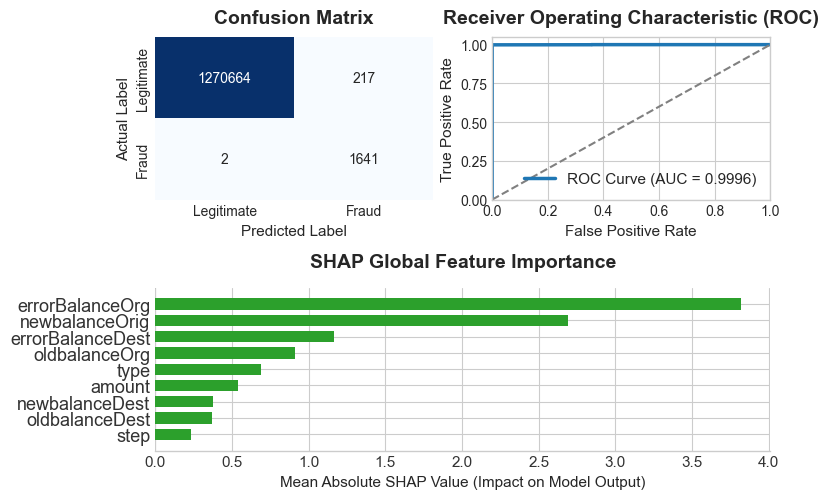

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc
import shap

# Set style for professional presentation charts
plt.style.use('seaborn-v0_8-whitegrid')
fig = plt.figure(figsize=(18, 12))

# 1. Confusion Matrix Heatmap
plt.subplot(2, 2, 1)
# Assuming y_test and y_pred are available from your test evaluation
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, 
            xticklabels=['Legitimate', 'Fraud'], yticklabels=['Legitimate', 'Fraud'])
plt.title('Confusion Matrix', fontsize=14, fontweight='bold', pad=10)
plt.xlabel('Predicted Label', fontsize=11)
plt.ylabel('Actual Label', fontsize=11)

# 2. ROC Curve
plt.subplot(2, 2, 2)
y_prob = model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, color='#1f77b4', lw=2.5, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1.5)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=11)
plt.ylabel('True Positive Rate', fontsize=11)
plt.title('Receiver Operating Characteristic (ROC)', fontsize=14, fontweight='bold', pad=10)
plt.legend(loc="lower right", fontsize=11)

# 3. SHAP Summary Plot (Global Feature Importance)
plt.subplot(2, 2, (3, 4))
explainer = shap.TreeExplainer(model)
# Sample a subset of X_test if dataset is massive to keep plotting fast
X_sample = X_test.sample(n=1000, random_state=42)
shap_values = explainer(X_sample)
shap.summary_plot(shap_values, X_sample, plot_type="bar", show=False, color='#2ca02c')
plt.title('SHAP Global Feature Importance', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Mean Absolute SHAP Value (Impact on Model Output)', fontsize=11)

plt.tight_layout()
plt.show()